<a href="https://colab.research.google.com/github/Jessicaamc/Pos_Ciencia_Dados_e_Analytics/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
    <img src="https://raw.githubusercontent.com/Jessicaamc/Pos_Ciencia_Dados_e_Analytics/main/pucrio.png" width="200">
</div>

<font color="#2E86C1"><h2>MVP Análise de Dados e Boas Práticas</h2></font>


**Nome:** Jéssica Alves de Melo Caetano

**Matrícula:** 4052025002261

**Dataset:** [Bank Marketing Dataset](https://github.com/Jessicaamc/Pos_Ciencia_Dados_e_Analytics/blob/main/bank.csv)



##DESCRIÇÃO DO PROBLEMA

O Bank Marketing Dataset contém dados de campanhas de marketing direto realizadas por uma instituição bancária, com o objetivo de promover a adesão de clientes a um depósito a prazo (deposit).
As campanhas foram realizadas principalmente por telefone, e cada linha do dataset representa o histórico de interação com um cliente específico.
O principal objetivo é prever se um cliente irá aderir (ou não) ao produto oferecido, com base em características demográficas, financeiras e informações da campanha. Dessa forma a instituição poderá reduzir custo de campanhas, melhorar taxa de conversão e direcionar contatos para clientes com maior probabilidade de sucesso.

###Hipóteses do Problema
1. Clientes com maior saldo têm maior chance de adesão
2. A duração da ligação influencia diretamente na conversão
3. Clientes já contatados anteriormente têm maior propensão

###Tipo de Problema
O problema abordado neste projeto é classificado como um caso de classificação supervisionada, cujo objetivo é prever se um cliente irá ou não aderir a um depósito. Nesse contexto, as variáveis de entrada são compostas por características dos clientes e informações relacionadas à campanha de marketing, enquanto a variável de saída é representada pela variável "deposit", que assume os valores “yes” ou “no”.
Para a resolução desse tipo de problema, podem ser aplicadas diferentes técnicas de machine learning, como Regressão Logística, Árvore de Decisão, Random Forest e XGBoost, que são amplamente utilizadas em problemas de classificação e permitem identificar padrões relevantes nos dados.

###Seleção de Dados
O dataset utilizado neste projeto foi obtido por meio da plataforma Kaggle, sendo denominado Bank Marketing Dataset. Sua origem está associada a campanhas de marketing direto realizadas por uma instituição bancária portuguesa.
A escolha desse dataset se justifica por se tratar de uma base realista e amplamente utilizada, contendo tanto variáveis categóricas quanto numéricas, o que possibilita uma análise mais abrangente.



###Atributos do Dataset
O dataset possui 17 colunas, sendo:

age: idade do cliente

job: profissão (admin., technician, services, etc.)

marital: estado civil (single, married, divorced)

education: nível educacional (primary, secondary, tertiary, unknown)

default: possui crédito em default? (yes/no)

balance: saldo médio anual da conta

housing: possui financiamento imobiliário? (yes/no)

loan: possui empréstimo pessoal? (yes/no)

contact: tipo de contato (cellular, telephone, unknown)

day: último dia de contato do mês

month: mês do contato

duration: duração da última ligação (em segundos)

campaign: número de contatos realizados durante a campanha atual

pdays: número de dias desde o último contato (-1 = nunca contatado)

previous: número de contatos anteriores

poutcome: resultado da campanha anterior (success, failure, unknown)

deposit: cliente aderiu ao depósito? (yes/no)

##IMPORTAÇÃO DAS BIBLIOTECAS E CARREGAMENTO DO DATASET






In [1]:
#importando as bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
#carregando o Dataset direto do GITHUB
df = pd.read_csv("https://raw.githubusercontent.com/Jessicaamc/Pos_Ciencia_Dados_e_Analytics/refs/heads/main/bank.csv")

In [3]:
#Exibindo primeiras linhas do Dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


##ANALISE EXPLORATÓRIA DE DADOS

O dataset Bank Marketing Dataset contém 11.162 linhas e possui 17 atributos.

In [4]:
#Verificando tamanho do dataset
df.shape

(11162, 17)

In [5]:
# Verificando informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
# Estatísticas Descritivas
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [7]:
# Resumo estatístico completo das variáveis numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

resumo = pd.DataFrame({
    'Mínimo':     df[num_cols].min(),
    'Máximo':     df[num_cols].max(),
    'Média':      df[num_cols].mean().round(2),
    'Mediana':    df[num_cols].median(),
    'Moda':       df[num_cols].mode().iloc[0],
    'Desvio-padrão': df[num_cols].std().round(2),
})
resumo

,Mínimo,Máximo,Média,Mediana,Moda,Desvio-padrão
age,18,95,41.23,39.0,31,11.91
balance,-6847,81204,1528.54,550.0,0,3225.41
day,1,31,15.66,15.0,20,8.42
duration,2,3881,371.99,255.0,97,347.13
campaign,1,63,2.51,2.0,1,2.72
pdays,-1,854,51.33,-1.0,-1,108.76
previous,0,58,0.83,0.0,0,2.29


A tabela acima consolida as principais medidas descritivas das variáveis numéricas:

- **age**: concentração entre 30 e 50 anos, com média próxima a 41.
- **balance**: alta variabilidade. Desvio-padrão elevado e grande diferença entre média e mediana indicam a presença de valores extremos (outliers). A moda é 0, o que sugere que muitos clientes não possuem saldo.
- **duration**: média elevada em relação à mediana. A maioria das ligações é curta, mas algumas são muito longas, puxando a média para cima.
- **campaign**: a maioria dos clientes foi contatada poucas vezes; o valor máximo elevado sugere outliers que merecem atenção.
- **pdays**: o valor -1 (nunca contatado) domina; a moda igual a -1 confirma que a maior parte dos clientes não tinha histórico de campanhas anteriores.
- **previous**: maioria com 0 contatos anteriores. Reforça que grande parte da base é composta por clientes abordados pela primeira vez.



In [8]:
#Identificando valores ausentes
df[num_cols].isnull().sum()

,0
age,0
balance,0
day,0
duration,0
campaign,0
pdays,0
previous,0


In [9]:
#Verificar valores nulos (missing values)
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [10]:
# Verificando se há "falsos nulos"
df.isin([" ", "None", "null", "N/A"]).sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [11]:
# Verificando se há valores inconsistentes(unknown) nos atributos categóricos
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
default
no     10994
yes      168
Name: count, dtype: int64
housing
no     5881
yes    5281
Name: count, dtype: int64
loan
no     9702
yes    1460
Name: count, dtype: int64
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64
poutcome
unknown    8326
failure    1228
success    1071
other       537
Nam

O dataset apresenta uma quantidade considerável de valores "unknown", indicando necessidade de tratamento posterior.

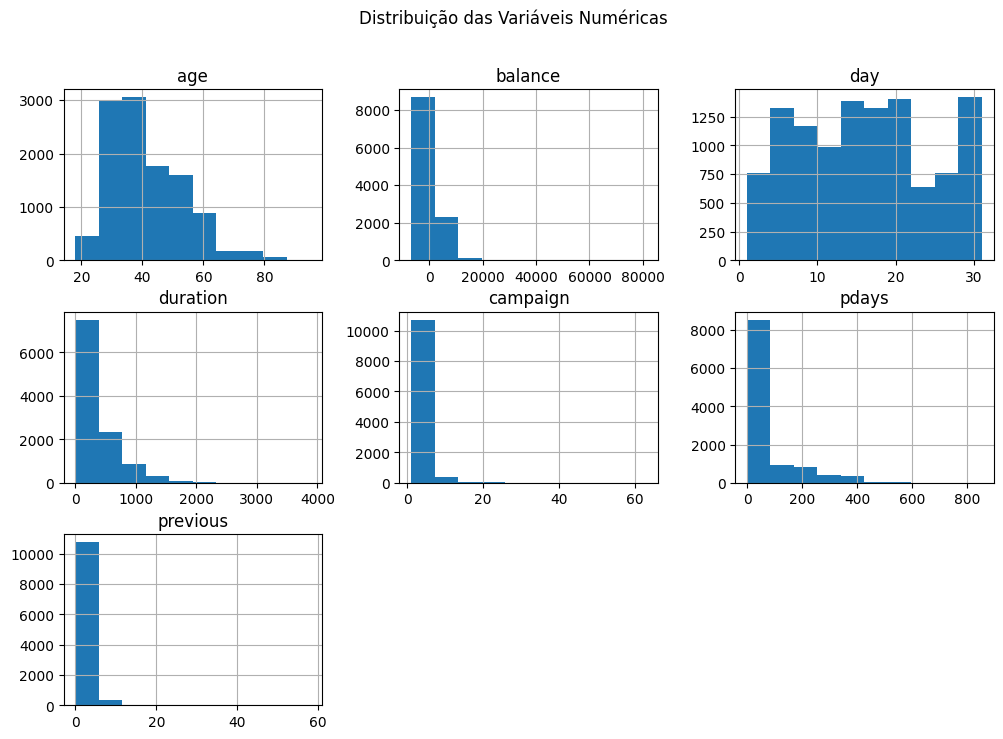

In [12]:
# Cria histograma para mostrar a distribuição de todas as variáveis numéricas
df[num_cols].hist(figsize=(12,8))
plt.suptitle('Distribuição das Variáveis Numéricas')
plt.show()

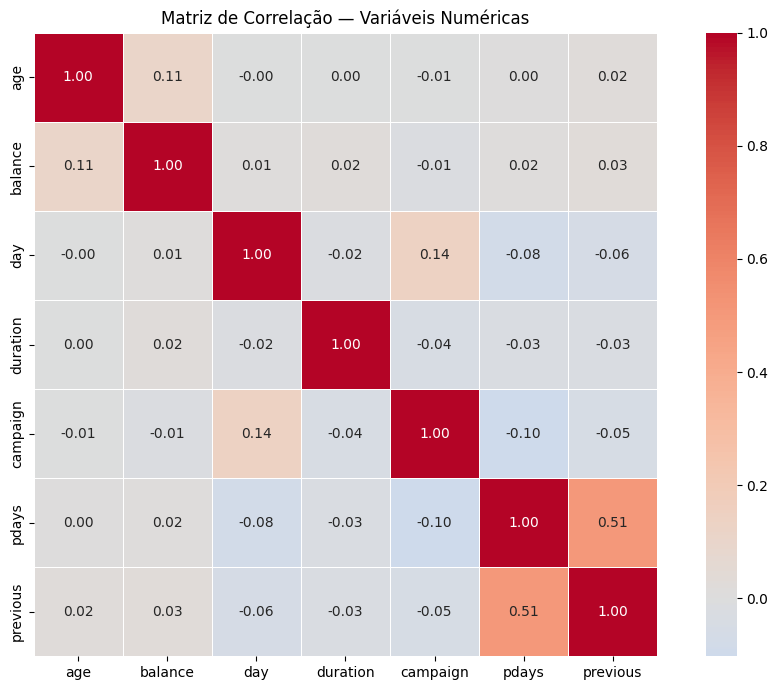

In [13]:
# Matriz de correlação entre variáveis numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 7))
corr_matrix = df[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Matriz de Correlação — Variáveis Numéricas')
plt.tight_layout()
plt.show()

A matriz de correlação revela as relações lineares entre as variáveis numéricas:

- **duration** apresenta a correlação mais relevante com a variável-alvo (quando analisada separadamente), confirmando a hipótese 2. Porém, como seu valor só é conhecido após o contato, ela não deve ser usada como feature em modelos preditivos reais.
- **pdays** e **previous** apresentam correlação positiva moderada entre si, o que é esperado: clientes com mais contatos anteriores tendem a ter histórico mais recente.
- **age** e **balance** têm correlação baixa com a maioria das variáveis, o que é positivo, indica independência entre os preditores e reduz o risco de multicolinearidade em modelos futuros.


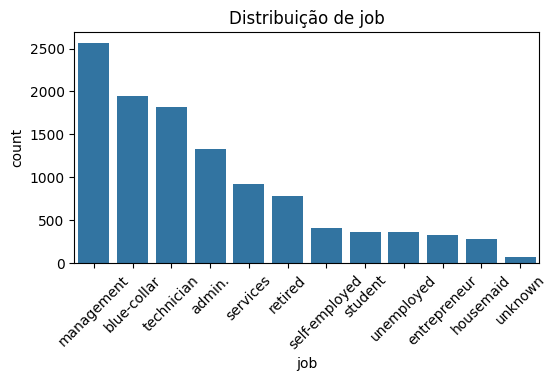

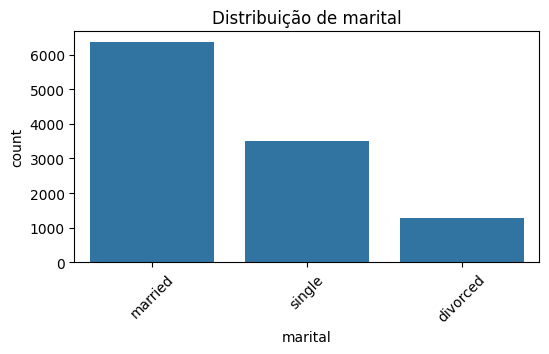

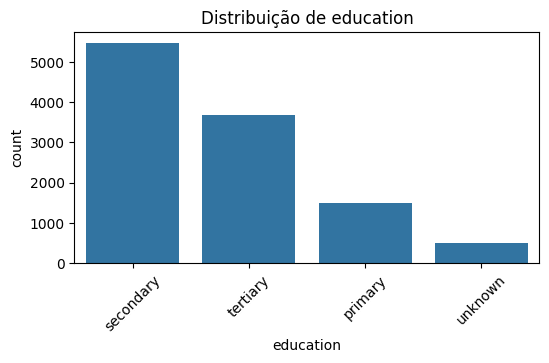

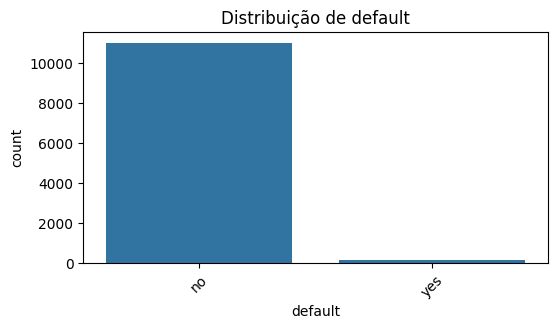

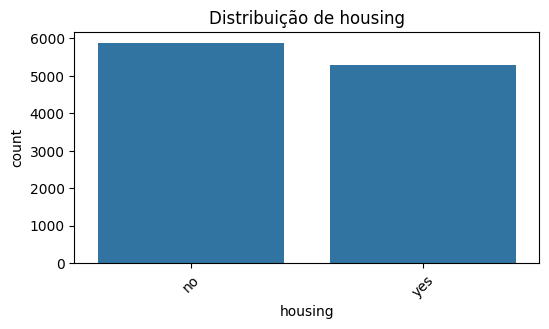

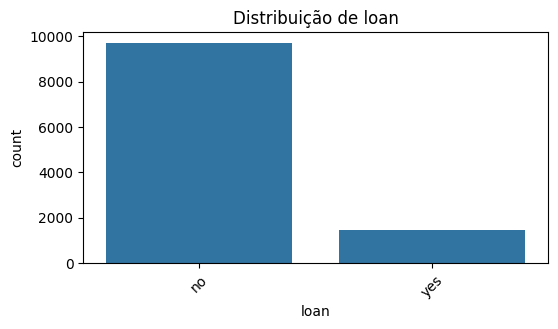

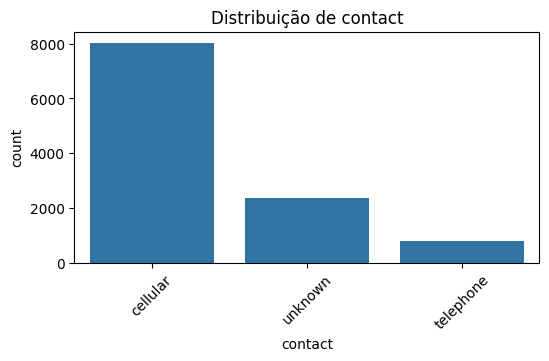

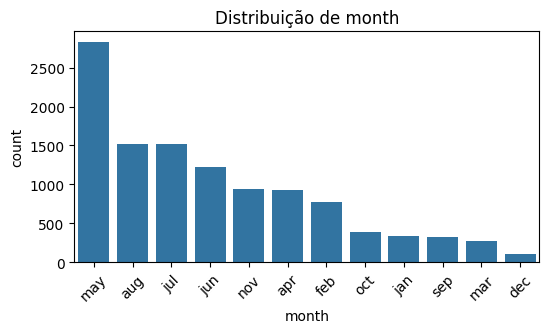

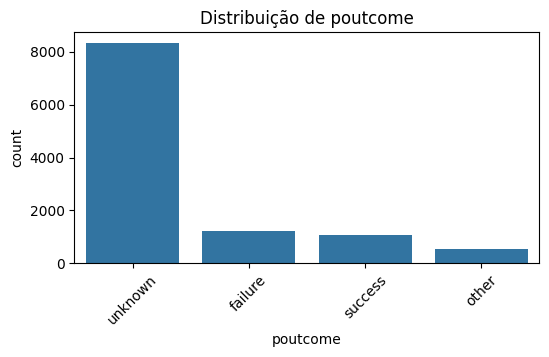

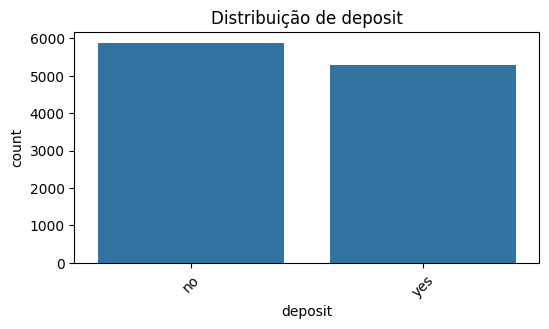

In [14]:
#Verificando as variáveis categóricas
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribuição de {col}')
    plt.xticks(rotation=45)
    plt.show()

As variáveis categóricas apresentam concentração em categorias específicas, com destaque para a presença significativa de valores "unknown", o que reforça a necessidade de tratamento desses dados.

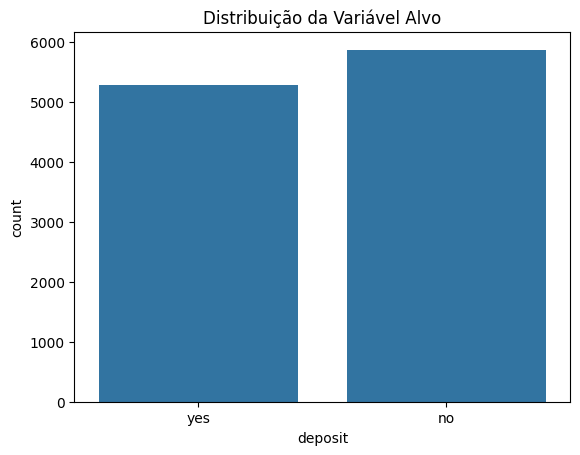

In [15]:
#Verificando a variável alvo(deposit)
sns.countplot(x='deposit', data=df)
plt.title('Distribuição da Variável Alvo')
plt.show()

Nessa análise prévia da variável alvo(atributo "depósit"), podemos observar que o número de clientes que fizeram o depósito(yes) foi menor do que o número de clientes que não fizeram(no).



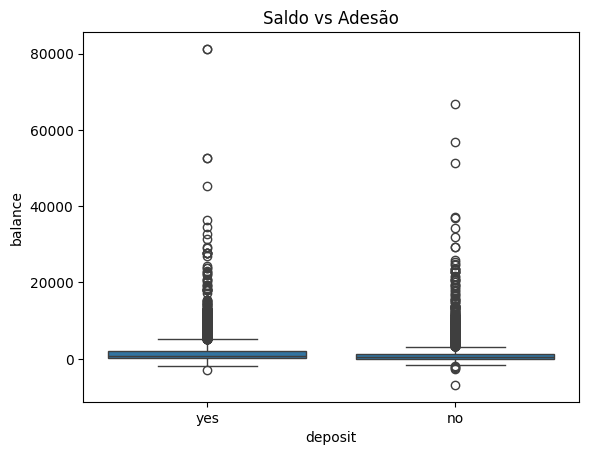

In [16]:
#Boxplot para visualizar o saldo x adesão
sns.boxplot(x='deposit', y='balance', data=df)
plt.title('Saldo vs Adesão')
plt.show()

O boxplot de "Saldo vs Adesão" revela que clientes que aderiram ao depósito (yes) apresentam mediana e amplitude interquartil levemente superiores aos que não aderiram (no), confirmando a hipótese 1 de que maior saldo está associado à maior taxa de conversão. A presença de muitos outliers em ambos os grupos é esperada para a variável balance, pois os saldos bancários são muito heterogêneos. A maioria dos clientes concentra-se em valores baixos, enquanto uma minoria possui saldos muito elevados.

In [17]:
#Verificando a média do saldo x adesão
df.groupby('deposit')['balance'].mean()

,balance
deposit,
no,1280.227141
yes,1804.267915


In [18]:
#Verificando a mediana do saldo x adesão
df.groupby('deposit')['balance'].median()

,balance
deposit,
no,414.0
yes,733.0


/tmp/ipykernel_3201/1418282272.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_balance')['deposit'].value_counts(normalize=True).unstack()['yes'].plot(kind='bar')


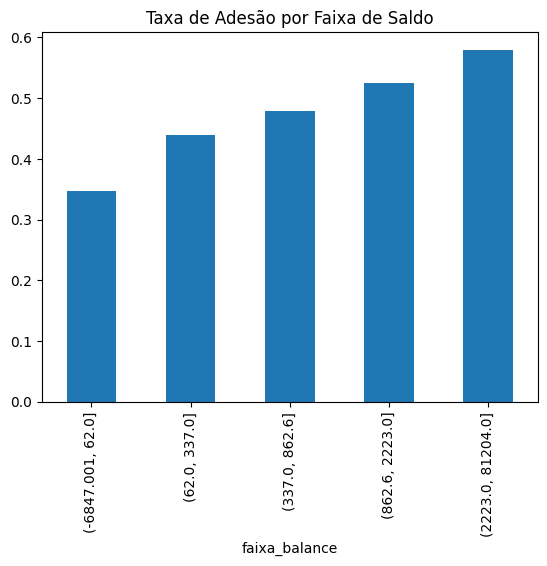

In [19]:
#Verificando a taxa de adesão por faixa de saldo
df['faixa_balance'] = pd.qcut(df['balance'], 5)
df.groupby('faixa_balance')['deposit'].value_counts(normalize=True).unstack()['yes'].plot(kind='bar')
plt.title('Taxa de Adesão por Faixa de Saldo')
plt.show()

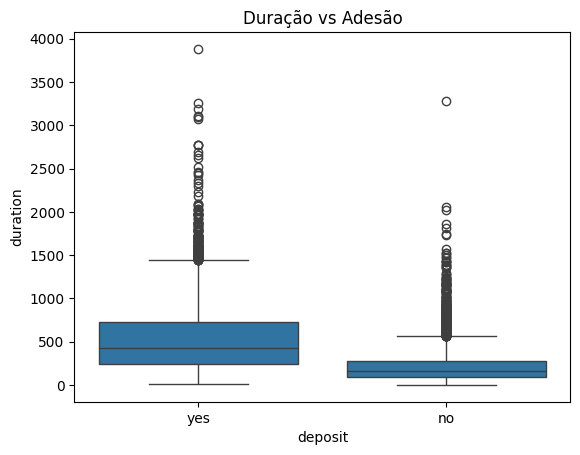

In [20]:
#Boxplot para verificar duração x adesão
sns.boxplot(x='deposit', y='duration', data=df)
plt.title('Duração vs Adesão')
plt.show()

Clientes que aderiram ao produto (yes) apresentam mediana de duração significativamente maior do que os que não aderiram (no), com a caixa inteira do grupo "yes" situada acima da caixa do grupo "no", evidência visual clara da relação entre tempo de ligação e conversão, confirmando a hipótese 2. Os outliers presentes representam ligações excepcionalmente longas, que provavelmente correspondem a clientes muito engajados durante o contato.

In [21]:
#Verificando média adesão x duração
df.groupby('deposit')['duration'].mean()


,duration
deposit,
no,223.130257
yes,537.294574


In [22]:
#Verificando mediana adesão x duração
df.groupby('deposit')['duration'].median()

,duration
deposit,
no,163.0
yes,426.0


/tmp/ipykernel_3201/3670106110.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_duration')['deposit'].value_counts(normalize=True).unstack()['yes'].plot(kind='bar')


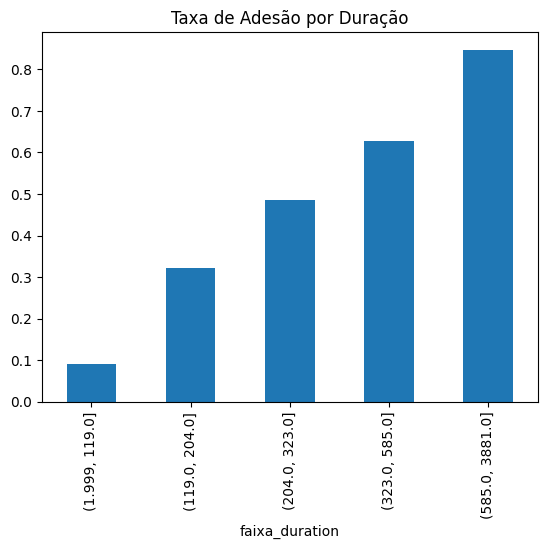

In [23]:
#Visualizando taxa de adesão por duração do contato
df['faixa_duration'] = pd.qcut(df['duration'], 5)

df.groupby('faixa_duration')['deposit'].value_counts(normalize=True).unstack()['yes'].plot(kind='bar')
plt.title('Taxa de Adesão por Duração')
plt.show()

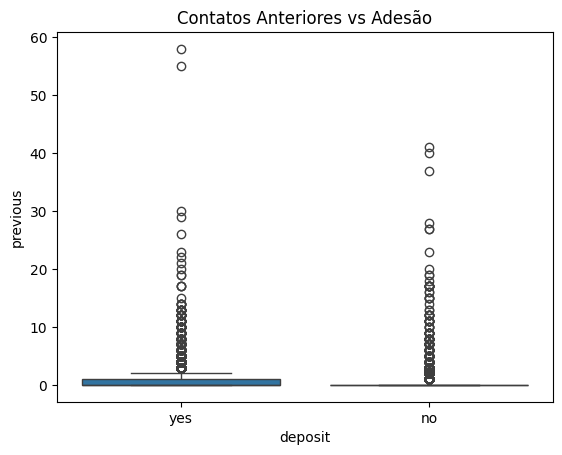

In [24]:
# Boxplot da adesão x contatos anteriores
sns.boxplot(x='deposit', y='previous', data=df)
plt.title('Contatos Anteriores vs Adesão')
plt.show()

O boxplot de "Contatos Anteriores vs Adesão" apresenta uma grande quantidade de pontos
classificados como outliers pelo critério IQR. Isso não indica erro nos dados, mas sim
uma característica da própria variável: a esmagadora maioria dos clientes possui
previous = 0 (nunca foram contatados), o que comprime a caixa próxima ao zero e faz
com que qualquer valor acima de 2 ou 3 seja matematicamente classificado como outlier. Essa concentração extrema em zero sugere que talvez seja mais informativo transformar
essa variável em uma categórica binária (foi contatado antes: sim/não) do que tratá-la
como numérica contínua.

In [25]:
#Verificando a média adesão x contatos anteriores
df.groupby('deposit')['previous'].mean()

,previous
deposit,
no,0.528350
yes,1.170354


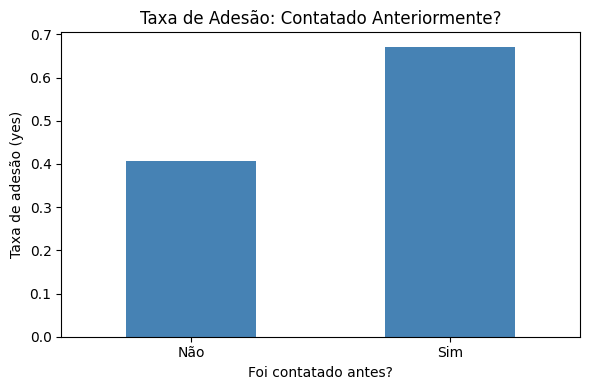

In [26]:
#Visualizando a taxa de adesão por número de contatos anteriores
df['foi_contatado'] = 'Não'
df.loc[df['previous'] > 0, 'foi_contatado'] = 'Sim'
df.groupby('foi_contatado')['deposit'] \
    .value_counts(normalize=True) \
    .unstack()['yes'] \
    .plot(kind='bar', color='steelblue', figsize=(6, 4))

plt.title('Taxa de Adesão: Contatado Anteriormente?')
plt.xlabel('Foi contatado antes?')
plt.ylabel('Taxa de adesão (yes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##TRATAMENTO DE VALORES NULOS

Como mencionado anteriormente, as variáveis categóricas possuem presença significativa de valores "unknown" sendo necessário o tratamento desses dados.



In [27]:
#Excluir as intâncias com valores "unknown" nas variáveis JOB e EDUCATION
df = df[(df['job'] != 'unknown') & (df['education'] != 'unknown')]

In [28]:
#Conferindo exclusão em JOB
df['job'].value_counts()

,count
job,
management,2482
blue-collar,1858
technician,1771
admin.,1294
services,882
retired,731
self-employed,394
unemployed,350
entrepreneur,314


In [36]:
#Conferindo exclusão em EDUCATION
df['education'].value_counts()

,count
education,
secondary,5461
tertiary,3680
primary,1493


As instâncias com valores "unknown" nas variáveis "job" e "education" foram removidas, uma vez que representam uma pequena parcela dos dados (inferior a 5%), não comprometendo a representatividade da amostra e contribuindo para a melhoria da qualidade das informações.

In [29]:
#Verificando se na variável CONTACT o valor "unknown" está como categoria
print(df['contact'].unique())

['unknown' 'cellular' 'telephone']


In [30]:
#Verificando se na variável POUTCOME o valor "unknown" está como categoria
print(df['poutcome'].unique())

['unknown' 'other' 'failure' 'success']


Para as variáveis "contact" e "poutcome", os valores "unknown" foram mantidos como uma categoria válida, devido à sua alta representatividade no dataset. A exclusão desses registros resultaria em perda significativa de dados, podendo comprometer a análise. Além disso, a manutenção dessa categoria permite capturar possíveis padrões associados à ausência de informação.

In [31]:
# Criando dataset tratado
df_clean = df.copy()

##PRÉ-PROCESSAMENTO DE DADOS


In [32]:
# Partir do dataset limpo
df_clean = df[(df['job'] != 'unknown') & (df['education'] != 'unknown')].copy()

# Remover colunas auxiliares criadas na análise (faixas)
for col in ['faixa_balance', 'faixa_duration']:
    if col in df_clean.columns:
        df_clean.drop(columns=[col], inplace=True)

print(f"Shape após limpeza: {df_clean.shape}")

Shape após limpeza: (10634, 18)


In [33]:
#PASSO 2: One-hot encoding das variáveis categóricas
# As variáveis binárias (yes/no) serão mapeadas para 0/1
# As demais categóricas receberão one-hot encoding

# Mapeamento das binárias
binarias = ['default', 'housing', 'loan', 'deposit']
for col in binarias:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

# One-hot encoding das categóricas nominais
cat_nominais = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_encoded = pd.get_dummies(df_clean, columns=cat_nominais, drop_first=False)

print(f"Shape após encoding: {df_encoded.shape}")
df_encoded.head(3)

Shape após encoding: (10634, 48)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,1,0,5,1042,1,-1,0,...,False,False,True,False,False,False,False,False,False,True
1,56,0,45,0,0,5,1467,1,-1,0,...,False,False,True,False,False,False,False,False,False,True
2,41,0,1270,1,0,5,1389,1,-1,0,...,False,False,True,False,False,False,False,False,False,True


In [34]:
#PASSO 3: Normalização
num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Normalização: escala [0, 1]
scaler_minmax = MinMaxScaler()
df_normalized = df_encoded.copy()
df_normalized[num_features] = scaler_minmax.fit_transform(df_encoded[num_features])

print("Dataset normalizado")
df_normalized[num_features].describe().round(3)

Dataset normalizado


,age,balance,day,duration,campaign,pdays,previous
count,10634.000,10634.000,10634.000,10634.000,10634.000,10634.000,10634.000
mean,0.299,0.095,0.488,0.096,0.036,0.061,0.014
std,0.152,0.037,0.280,0.090,0.063,0.127,0.040
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.182,0.079,0.233,0.035,0.000,0.000,0.000
50%,0.260,0.084,0.467,0.065,0.024,0.000,0.000
75%,0.403,0.097,0.667,0.128,0.048,0.017,0.017
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [35]:
#PASSO 4: Padronização
# Padronização: média 0, desvio-padrão 1
scaler_std = StandardScaler()
df_standardized = df_encoded.copy()
df_standardized[num_features] = scaler_std.fit_transform(df_encoded[num_features])

print("Dataset padronizado")
df_standardized[num_features].describe().round(3)

Dataset padronizado


,age,balance,day,duration,campaign,pdays,previous
count,10634.000,10634.000,10634.000,10634.000,10634.000,10634.000,10634.000
mean,0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.962,-2.594,-1.742,-1.063,-0.570,-0.480,-0.362
25%,-0.769,-0.434,-0.909,-0.674,-0.570,-0.480,-0.362
50%,-0.258,-0.303,-0.076,-0.339,-0.190,-0.480,-0.362
75%,0.679,0.054,0.638,0.363,0.189,-0.345,0.070
max,4.598,24.714,1.828,10.045,15.386,7.370,24.666


As operações de pré-processamento foram realizadas em etapas:

**Passo 1 — Limpeza:** partiu-se do dataset já tratado (sem "unknown" em job e education), removendo também as colunas auxiliares criadas durante a análise exploratória (faixas de saldo e duração).

**Passo 2 — Encoding:**
- Variáveis binárias (default, housing, loan, deposit) foram mapeadas diretamente para 0/1.
- Variáveis categóricas nominais (job, marital, education, contact, month, poutcome) receberam one-hot encoding, criando uma coluna binária por categoria.

**Passo 3 — Normalização Min-Max:** transforma os valores numéricos para o intervalo [0, 1].

**Passo 4 — Padronização Z-score:** centraliza os dados em média 0 com desvio-padrão 1.


##RESPONDENDO AS HIPÓTESES

1. Clientes com maior saldo têm maior chance de adesão

A análise da variável "balance" em relação à adesão ao depósito indica que clientes com maior saldo apresentam maior probabilidade de conversão. Observou-se que tanto a média quanto a mediana do saldo são superiores entre os clientes que aderiram ao produto. Além disso, a análise por faixas de saldo evidenciou um aumento progressivo na taxa de adesão conforme o saldo se eleva, reforçando a hipótese de que clientes com maior capacidade financeira tendem a aceitar mais facilmente a oferta.

2. A duração da ligação influencia diretamente na conversão

A variável "duration" demonstrou forte relação com a adesão ao produto. Clientes que permaneceram mais tempo em contato com a instituição apresentaram taxas significativamente maiores de conversão. A análise por faixas de duração evidenciou um aumento expressivo na proporção de respostas positivas à medida que o tempo de ligação cresce. No entanto, é importante destacar que essa variável não deve ser utilizada em modelos preditivos reais, uma vez que seu valor só é conhecido após a realização do contato.

3. Clientes já contatados anteriormente têm maior propensão

A análise da variável "previous" indica que clientes que já foram contatados anteriormente apresentam uma leve tendência maior de adesão ao produto. Observou-se que, à medida que o número de contatos anteriores aumenta, há um crescimento na taxa de conversão, ainda que de forma menos acentuada quando comparada a outras variáveis. Esse comportamento sugere que o histórico de relacionamento com o cliente pode influenciar positivamente sua decisão.

##CONCLUSÃO

O presente projeto teve como objetivo analisar dados de campanhas de marketing bancário, com foco na identificação de fatores que influenciam a adesão de clientes a um depósito a prazo. Para isso, foram realizadas etapas de análise exploratória, tratamento de dados e validação de hipóteses, permitindo uma compreensão mais aprofundada do comportamento dos clientes.

Inicialmente, a análise exploratória dos dados possibilitou identificar padrões relevantes e inconsistências no dataset, com destaque para a presença de valores categóricos classificados como "unknown". Diante disso, foi adotada uma estratégia de tratamento. Nas variáveis "job" e "education", os registros com valores "unknown" foram removidos por representarem uma pequena parcela da base, enquanto nas variáveis "contact" e "poutcome" esses valores foram mantidos como uma categoria válida, devido à sua alta frequência e potencial relevância analítica.

Em relação às hipóteses propostas, os resultados obtidos indicaram que:

Clientes com maior saldo (balance) apresentam maior probabilidade de adesão ao produto, evidenciado por maiores valores de média, mediana e taxas de conversão nas faixas mais elevadas;
A duração da ligação (duration) demonstrou forte influência na conversão, com aumento significativo da taxa de adesão em chamadas mais longas, embora essa variável não seja adequada para uso em modelos preditivos em cenários reais;
Clientes previamente contatados (previous) apresentaram uma leve tendência de maior propensão à adesão, sugerindo que o histórico de interação pode impactar positivamente a decisão do cliente;
O tipo de contato (contact) influencia os resultados da campanha, sendo observadas diferenças nas taxas de conversão entre os canais utilizados, além da relevância dos registros classificados como "unknown".

Durante a análise, também foram identificados possíveis valores extremos em variáveis como "balance" e "duration". No entanto, optou-se por não realizar a remoção desses outliers neste MVP, considerando que tais valores podem representar comportamentos reais dos clientes. Além disso, essa decisão foi tomada com o objetivo de manter a integridade dos dados e o foco principal do projeto, que está voltado ao tratamento de valores ausentes e à análise exploratória.

Por fim, foi realizada a etapa de pré-processamento dos dados incluindo as técnicas de encoding e one-hot encoding, bem como normalização e padronização.

Dessa forma, o projeto atingiu seus objetivos ao identificar variáveis relevantes para a adesão ao produto. Os resultados obtidos servem como base para etapas futuras, como a construção e avaliação de modelos de machine learning, visando otimizar estratégias de marketing e aumentar a eficiência das campanhas.